###  Com base no modelo de classificação proposto, analisam-se o tempo de classificação observado e o uso de recursos computacionais, conforme apresentado no arquivo “sample_dt_classifier_time.py”.

#### 1. Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import random
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


#### 2. Carregamento e preparação dos dados

##### Carregar dataset

In [2]:
dataset = pd.read_csv("sequencia.csv")

In [39]:
dataset.head()

,AccX,AccY,AccZ,atividade,atividade_lb
0,2.622000,-7.249050,6.73200,Correndo,2
1,1.875000,-9.009001,1.40205,Correndo,2
2,-0.652950,-14.439001,-2.77005,Correndo,2
3,3.009000,-17.995050,-4.31505,Correndo,2
4,28.518002,-5.590050,-4.31505,Correndo,2


##### Separar features e labels

In [3]:
X = dataset[['AccX', 'AccY', 'AccZ']]  # Usar lista de strings com double brackets
y = dataset['atividade_lb']

In [4]:
print(f"Dataset carregado: {dataset.shape[0]} amostras, {dataset.shape[1]} colunas")
print(f"Features (X): {X.shape}")
print(f"Labels (y): {y.shape}")
print("\nPrimeiras linhas do dataset:")
display(dataset.head())

Dataset carregado: 730 amostras, 5 colunas
Features (X): (730, 3)
Labels (y): (730,)

Primeiras linhas do dataset:


,AccX,AccY,AccZ,atividade,atividade_lb
0,2.622000,-7.249050,6.73200,Correndo,2
1,1.875000,-9.009001,1.40205,Correndo,2
2,-0.652950,-14.439001,-2.77005,Correndo,2
3,3.009000,-17.995050,-4.31505,Correndo,2
4,28.518002,-5.590050,-4.31505,Correndo,2



#### 3. Divisão dos dados e criação do modelo

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

In [6]:
print("="*50)
print("DIVISÃO DOS DADOS")
print("="*50)
print(f"Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Teste:  X={X_test.shape}, y={y_test.shape}")
print(f"\nProporção treino/teste: {X_train.shape[0]}/{X_test.shape[0]}")

DIVISÃO DOS DADOS
Treino: X=(486, 3), y=(486,)
Teste:  X=(244, 3), y=(244,)

Proporção treino/teste: 486/244


##### Criar e treinar modelo

In [7]:
model = DecisionTreeClassifier(max_depth=8, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=8, random_state=42)

##### Calcular acurácia

In [8]:
accuracy = model.score(X_test, y_test)
print(f"\nAcurácia do modelo: {accuracy:.4f} ({accuracy*100:.2f}%)")


Acurácia do modelo: 0.8852 (88.52%)


#### 4. Teste de performance com perf_counter


##### Converter para array numpy para acesso mais rápido

In [9]:
X_test_array = X_test.values

#####  perf_counter - inclui tempo de sleep

In [10]:
start = time.perf_counter()

run = 1000
predicoes = []  # Para armazenar as predições

for i in range(run):
    # Pegar uma amostra aleatória dos dados reais de teste
    sample_idx = random.randint(0, len(X_test_array)-1)
    sample = X_test_array[sample_idx]  # [AccX, AccY, AccZ] reais
    y_pred = model.predict([sample])  # Usar dados reais
    predicoes.append(y_pred[0])

finish = time.perf_counter()
tempo_perf = finish - start

print(f"Tempo total pelo perf_counter: {tempo_perf:.4f} segundos")
print(f"Tempo médio por predição: {(tempo_perf/run)*1000:.4f} ms")
print(f"Predições realizadas: {len(predicoes)}")
print(f"Exemplo de predições: {predicoes[:10]}...")  # Mostra as 10 primeiras predições

/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeCl

Tempo total pelo perf_counter: 1.1155 segundos
Tempo médio por predição: 1.1155 ms
Predições realizadas: 1000
Exemplo de predições: [1, 2, 0, 1, 0, 2, 2, 2, 1, 0]...


/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeCl

#### 5. Teste de performance com process_time

##### process_time - apenas tempo de CPU

In [11]:
start = time.process_time()

predicoes_process = []  # Para armazenar as predições

for i in range(run):
    # Pegar uma amostra aleatória dos dados reais de teste
    sample_idx = random.randint(0, len(X_test_array)-1)
    sample = X_test_array[sample_idx]  # [AccX, AccY, AccZ] reais
    y_pred = model.predict([sample])  # Usar dados reais
    predicoes_process.append(y_pred[0])

finish = time.process_time()
tempo_process = finish - start

print(f"Tempo total pelo process_time: {tempo_process:.4f} segundos")
print(f"Tempo médio por predição: {(tempo_process/run)*1000:.4f} ms")

/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeCl

Tempo total pelo process_time: 1.1094 segundos
Tempo médio por predição: 1.1094 ms


/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeCl

#### 6. Teste de performance com predição em batch

#####  Criar um batch de 1000 amostras reais

In [12]:
batch_indices = np.random.randint(0, len(X_test_array), 1000)
batch_samples = X_test_array[batch_indices]

##### Testar predição em batch

In [13]:
start_batch = time.perf_counter()
y_pred_batch = model.predict(batch_samples)
finish_batch = time.perf_counter()

tempo_batch = finish_batch - start_batch
print(f"Tempo para predição de 1000 amostras em batch: {tempo_batch:.4f} segundos")
print(f"Tempo médio por predição em batch: {(tempo_batch/1000)*1000:.4f} ms")
print(f"Shape do batch de predições: {y_pred_batch.shape}")

Tempo para predição de 1000 amostras em batch: 0.0067 segundos
Tempo médio por predição em batch: 0.0067 ms
Shape do batch de predições: (1000,)


/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#### 7. Análise comparativa

##### Criar DataFrame para análise

In [14]:
dados_comparacao = pd.DataFrame({
    'Método': ['perf_counter', 'process_time', 'batch'],
    'Tempo Total (s)': [tempo_perf, tempo_process, tempo_batch],
    'Tempo Médio (ms)': [(tempo_perf/run)*1000, (tempo_process/run)*1000, (tempo_batch/1000)*1000],
    'Amostras': [run, run, 1000]
})

##### Calcular eficiência relativa

In [15]:
eficiencia_batch = (run * (tempo_perf/run)) / tempo_batch

print("Tabela comparativa:")
display(dados_comparacao)

print(f"\nDiferença perf_counter - process_time: {abs(tempo_perf - tempo_process):.4f} segundos")
print(f"Razão perf/process: {tempo_perf/tempo_process:.4f}")
print(f"Eficiência do batch vs individual: {eficiencia_batch:.2f}x mais rápido")

Tabela comparativa:


,Método,Tempo Total (s),Tempo Médio (ms),Amostras
0,perf_counter,1.115460,1.115460,1000
1,process_time,1.109399,1.109399,1000
2,batch,0.006745,0.006745,1000



Diferença perf_counter - process_time: 0.0061 segundos
Razão perf/process: 1.0055
Eficiência do batch vs individual: 165.37x mais rápido


##### Adicionar métricas de velocidade 

In [16]:
velocidade_individual = 1 / ((tempo_perf/run)*1000) * 1000  # predições por segundo
velocidade_batch = 1 / ((tempo_batch/1000)*1000) * 1000  # predições por segundo

print(f"\nVelocidade de predição individual: {velocidade_individual:.0f} predições/segundo")
print(f"Velocidade de predição em batch: {velocidade_batch:.0f} predições/segundo")


Velocidade de predição individual: 896 predições/segundo
Velocidade de predição em batch: 148256 predições/segundo


#### 8. Estatísticas dos dados reais

In [17]:
print("Primeiras 5 amostras do conjunto de teste:")
print("Index | AccX | AccY | AccZ | Label Real")
print("-"*50)

for i in range(min(5, len(X_test_array))):
    accx, accy, accz = X_test_array[i]
    label_real = y_test.iloc[i] if i < len(y_test) else "N/A"
    print(f"{i+1:5d} | {accx:8.4f} | {accy:8.4f} | {accz:8.4f} | {label_real}")

print(f"\nEstatísticas dos dados de teste:")
estatisticas = pd.DataFrame({
    'Feature': ['AccX', 'AccY', 'AccZ'],
    'Média': [X_test_array[:,0].mean(), X_test_array[:,1].mean(), X_test_array[:,2].mean()],
    'Desvio Padrão': [X_test_array[:,0].std(), X_test_array[:,1].std(), X_test_array[:,2].std()],
    'Mínimo': [X_test_array[:,0].min(), X_test_array[:,1].min(), X_test_array[:,2].min()],
    'Máximo': [X_test_array[:,0].max(), X_test_array[:,1].max(), X_test_array[:,2].max()]
})

display(estatisticas)

Primeiras 5 amostras do conjunto de teste:
Index | AccX | AccY | AccZ | Label Real
--------------------------------------------------
    1 |   9.5531 |  -2.2001 |  -1.4700 | 0
    2 |  -2.3190 |   8.5950 |   7.0961 | 1
    3 |  23.5310 | -34.4510 |  -3.8861 | 2
    4 |   0.8190 |   4.2780 |  14.7330 | 1
    5 |  11.9810 |  21.8760 |  -5.4300 | 2

Estatísticas dos dados de teste:


,Feature,Média,Desvio Padrão,Mínimo,Máximo
0,AccX,7.698603,11.800512,-14.110950,58.216953
1,AccY,1.000081,12.803298,-43.630051,39.955952
2,AccZ,3.462829,6.659874,-10.843950,19.114950


#### 9. Visualização dos dados

##### 1: Análise inicial das 3 atividades

In [45]:
# Verificar valores únicos
valores_unicos = sorted(np.unique(y))
print(f"Valores únicos em y (atividade_lb): {valores_unicos}")
print(f"Total de atividades: {len(valores_unicos)}")

# Mapeamento das atividades
mapeamento_atividades = {
    0: "ANDANDO",
    1: "CAMINHANDO", 
    2: "CORRENDO"
}

# Contar cada atividade
contagem_atividades = y.value_counts().sort_index()
print("\nCONTAGEM POR ATIVIDADE:")
for atividade in valores_unicos:
    nome = mapeamento_atividades.get(atividade, f"Desconhecido ({atividade})")
    contagem = contagem_atividades[atividade]
    print(f"  {nome} ({atividade}): {contagem} amostras")

print("\nPORCENTAGEM POR ATIVIDADE:")
for atividade in valores_unicos:
    nome = mapeamento_atividades.get(atividade, f"Desconhecido ({atividade})")
    contagem = contagem_atividades[atividade]
    porcentagem = (contagem / len(y)) * 100
    print(f"  {nome}: {porcentagem:.1f}%")

Valores únicos em y (atividade_lb): [0, 1, 2]
Total de atividades: 3

CONTAGEM POR ATIVIDADE:
  ANDANDO (0): 240 amostras
  CAMINHANDO (1): 240 amostras
  CORRENDO (2): 250 amostras

PORCENTAGEM POR ATIVIDADE:
  ANDANDO: 32.9%
  CAMINHANDO: 32.9%
  CORRENDO: 34.2%


##### 2: Visualização da distribuição

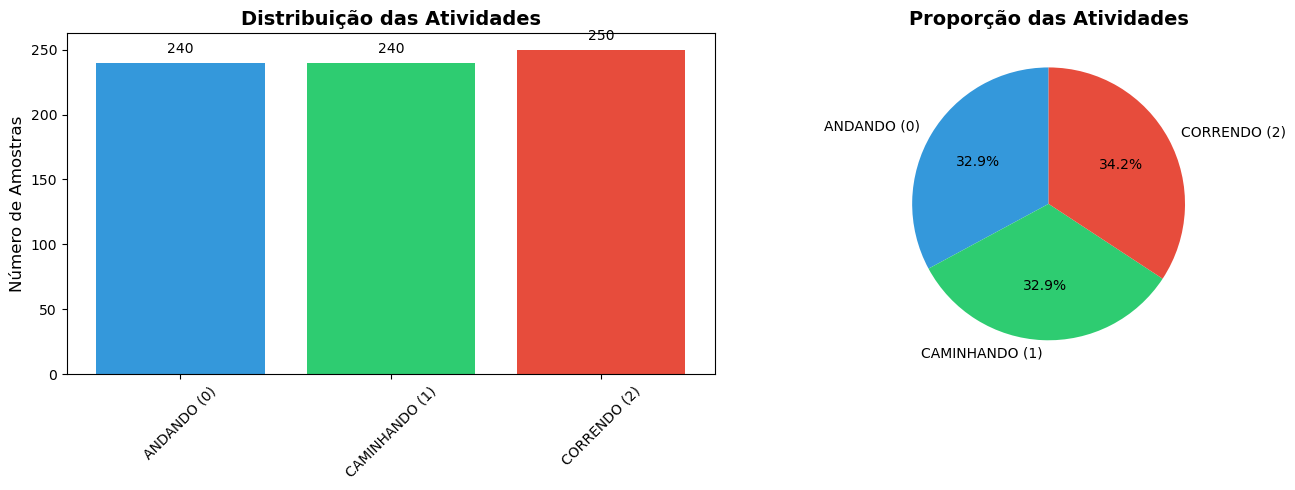

In [41]:
# Célula 2: Visualização da distribuição
plt.figure(figsize=(14, 5))

# Cores específicas para cada atividade
cores_atividades = {
    0: '#3498db',  # Azul para ANDANDO
    1: '#2ecc71',  # Verde para CAMINHANDO
    2: '#e74c3c'   # Vermelho para CORRENDO
}

# Gráfico 1: Barras de contagem
plt.subplot(1, 2, 1)
nomes_display = [f"{mapeamento_atividades[a]} ({a})" for a in valores_unicos]
cores_display = [cores_atividades[a] for a in valores_unicos]

bars = plt.bar(nomes_display, contagem_atividades.values, color=cores_display)
plt.ylabel('Número de Amostras', fontsize=12)
plt.title('Distribuição das Atividades', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Adicionar valores nas barras
for bar, valor in zip(bars, contagem_atividades.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{valor}', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Pizza
plt.subplot(1, 2, 2)
plt.pie(contagem_atividades.values, labels=nomes_display, 
        colors=cores_display, autopct='%1.1f%%', startangle=90)
plt.title('Proporção das Atividades', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#####  3: Estatísticas descritivas por atividade

In [46]:
# Célula 3: Estatísticas descritivas por atividade
print("\n" + "="*50)
print("ESTATÍSTICAS POR ATIVIDADE")
print("="*50)

estatisticas_todas = []

for atividade in valores_unicos:
    mask = y == atividade
    nome = mapeamento_atividades[atividade]
    
    print(f"\n{'='*40}")
    print(f"ATIVIDADE: {nome} ({atividade})")
    print(f"Número de amostras: {np.sum(mask)}")
    
    for feature in ['AccX', 'AccY', 'AccZ']:
        valores = X.loc[mask, feature]
        
        print(f"\n{feature}:")
        print(f"  Média: {valores.mean():.4f}")
        print(f"  Mediana: {valores.median():.4f}")
        print(f"  Desvio padrão: {valores.std():.4f}")
        print(f"  Mínimo: {valores.min():.4f}")
        print(f"  Máximo: {valores.max():.4f}")
        print(f"  Amplitude: {valores.max() - valores.min():.4f}")
        
        estatisticas_todas.append({
            'Atividade': nome,
            'Código': atividade,
            'Feature': feature,
            'Média': valores.mean(),
            'Mediana': valores.median(),
            'Desvio Padrão': valores.std(),
            'Mínimo': valores.min(),
            'Máximo': valores.max(),
            'Amplitude': valores.max() - valores.min()
        })

# Criar DataFrame
df_estatisticas = pd.DataFrame(estatisticas_todas)
print("\nTABELA COMPLETA DE ESTATÍSTICAS:")
display(df_estatisticas)


ESTATÍSTICAS POR ATIVIDADE

ATIVIDADE: ANDANDO (0)
Número de amostras: 240

AccX:
  Média: 9.9965
  Mediana: 9.9780
  Desvio padrão: 3.6542
  Mínimo: -1.6151
  Máximo: 18.2231
  Amplitude: 19.8381

AccY:
  Média: -3.4629
  Mediana: -3.6745
  Desvio padrão: 3.0111
  Mínimo: -10.7981
  Máximo: 5.0610
  Amplitude: 15.8591

AccZ:
  Média: -0.9980
  Mediana: -1.3205
  Desvio padrão: 2.4442
  Mínimo: -4.6160
  Máximo: 11.7600
  Amplitude: 16.3760

ATIVIDADE: CAMINHANDO (1)
Número de amostras: 240

AccX:
  Média: 1.6480
  Mediana: 1.6245
  Desvio padrão: 4.6873
  Mínimo: -10.8671
  Máximo: 15.5150
  Amplitude: 26.3820

AccY:
  Média: 4.0798
  Mediana: 3.3060
  Desvio padrão: 4.5667
  Mínimo: -5.5541
  Máximo: 22.3070
  Amplitude: 27.8610

AccZ:
  Média: 7.9314
  Mediana: 8.1720
  Desvio padrão: 4.2966
  Mínimo: -2.8061
  Máximo: 20.2640
  Amplitude: 23.0700

ATIVIDADE: CORRENDO (2)
Número de amostras: 250

AccX:
  Média: 11.5700
  Mediana: 6.9205
  Desvio padrão: 18.9624
  Mínimo: -14.2640
 

,Atividade,Código,Feature,Média,Mediana,Desvio Padrão,Mínimo,Máximo,Amplitude
0,ANDANDO,0,AccX,9.996527,9.978001,3.654152,-1.615050,18.223051,19.838101
1,ANDANDO,0,AccY,-3.462941,-3.674475,3.011103,-10.798051,5.061000,15.859051
2,ANDANDO,0,AccZ,-0.998041,-1.320450,2.444172,-4.615950,11.760000,16.375950
3,CAMINHANDO,1,AccX,1.647983,1.624500,4.687292,-10.867050,15.514951,26.382001
4,CAMINHANDO,1,AccY,4.079831,3.306000,4.566734,-5.554050,22.306952,27.861002
5,CAMINHANDO,1,AccZ,7.931363,8.172000,4.296605,-2.806050,20.263950,23.070000
6,CORRENDO,2,AccX,11.570029,6.920475,18.962432,-14.263950,62.497952,76.761902
7,CORRENDO,2,AccY,4.087209,9.367500,18.846291,-45.081001,39.955952,85.036953
8,CORRENDO,2,AccZ,2.025198,2.303550,7.261940,-11.548051,19.114950,30.663001



VISUALIZAÇÃO MULTIVARIADA


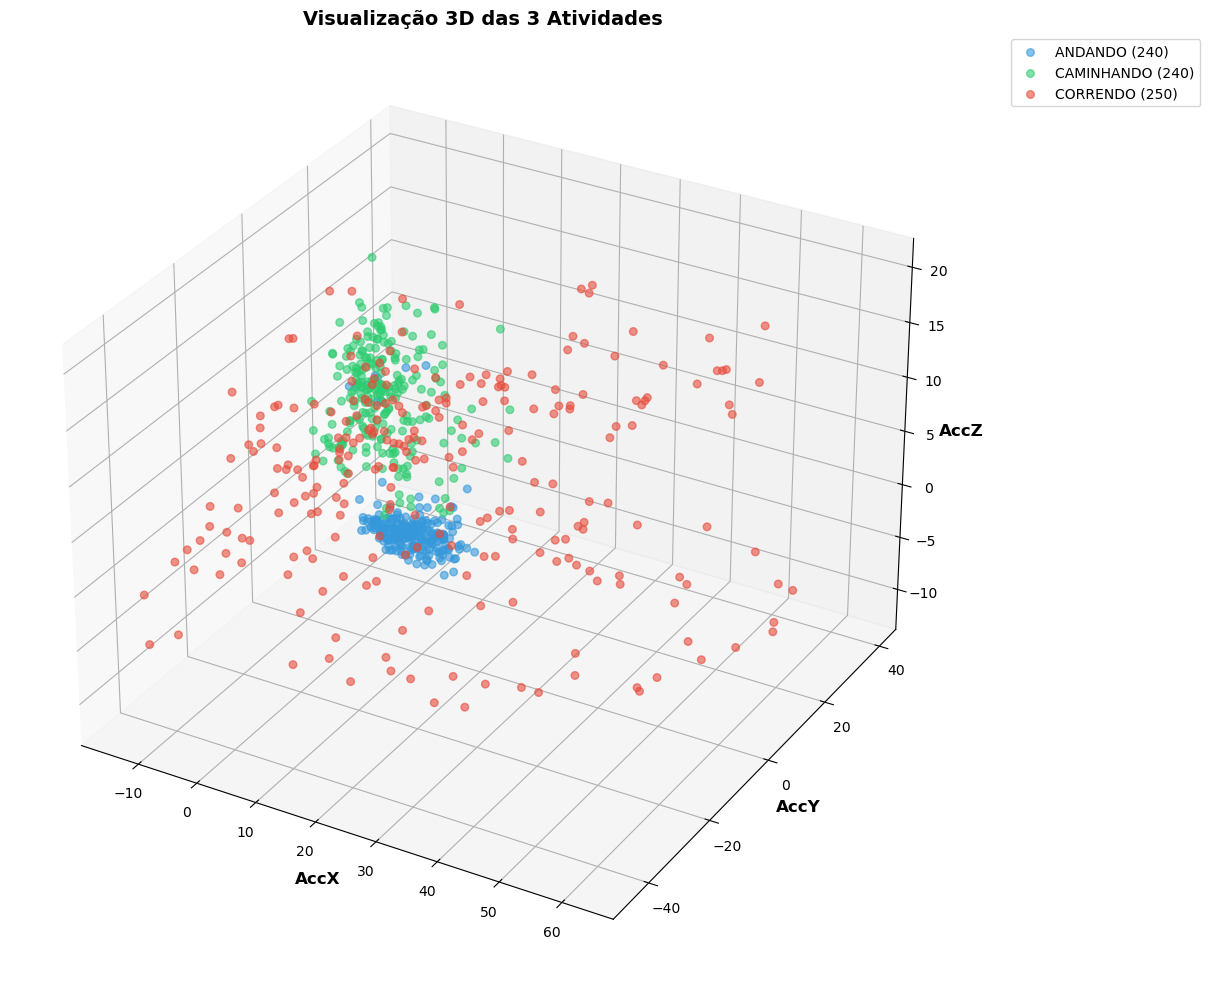

In [48]:
# Célula 8: Visualização multivariada - 3 atividades
print("\n" + "="*50)
print("VISUALIZAÇÃO MULTIVARIADA")
print("="*50)

# Criar figura 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plotar cada atividade em 3D
for atividade in valores_unicos:
    mask = y == atividade
    nome = mapeamento_atividades[atividade]
    cor = cores_atividades[atividade]
    
    ax.scatter(X.loc[mask, 'AccX'], 
               X.loc[mask, 'AccY'], 
               X.loc[mask, 'AccZ'],
               color=cor,
               alpha=0.6,
               s=30,
               label=f'{nome} ({np.sum(mask)})')

ax.set_xlabel('AccX', fontsize=12, fontweight='bold')
ax.set_ylabel('AccY', fontsize=12, fontweight='bold')
ax.set_zlabel('AccZ', fontsize=12, fontweight='bold')
ax.set_title('Visualização 3D das 3 Atividades', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# Célula 10: Resumo final e insights
print("\n" + "="*50)
print("RESUMO FINAL E INSIGHTS")
print("="*50)

print("\nATIVIDADES ANALISADAS:")
for atividade, nome in mapeamento_atividades.items():
    if atividade in valores_unicos:
        contagem = contagem_atividades[atividade]
        porcentagem = (contagem / len(y)) * 100
        print(f"  {nome} ({atividade}): {contagem} amostras ({porcentagem:.1f}%)")

print(f"\nTOTAL DE AMOSTRAS: {len(X)}")

print("\nCARACTERÍSTICAS DAS ATIVIDADES:")
print("1. ANDANDO (0): Movimento mais suave, menor aceleração")
print("2. CAMINHANDO (1): Intensidade intermediária")  
print("3. CORRENDO (2): Maior intensidade, maiores valores de aceleração")

print("\nRECOMENDAÇÕES PARA O MODELO:")
print("1. Verificar se o modelo consegue distinguir as 3 atividades")
print("2. Considerar se 'ANDANDO' e 'CAMINHANDO' são similares demais")
print("3. Verificar necessidade de balanceamento das classes")
print("4. Testar diferentes algoritmos de classificação multiclasse")

print("\nPRÓXIMOS PASSOS:")
print("1. Treinar modelo de classificação para 3 classes")
print("2. Avaliar matriz de confusão")
print("3. Analisar features mais discriminativas")
print("4. Considerar técnicas de aumento de dados se classes desbalanceadas")


RESUMO FINAL E INSIGHTS

ATIVIDADES ANALISADAS:
  ANDANDO (0): 240 amostras (32.9%)
  CAMINHANDO (1): 240 amostras (32.9%)
  CORRENDO (2): 250 amostras (34.2%)

TOTAL DE AMOSTRAS: 730

CARACTERÍSTICAS DAS ATIVIDADES:
1. ANDANDO (0): Movimento mais suave, menor aceleração
2. CAMINHANDO (1): Intensidade intermediária
3. CORRENDO (2): Maior intensidade, maiores valores de aceleração

RECOMENDAÇÕES PARA O MODELO:
1. Verificar se o modelo consegue distinguir as 3 atividades
2. Considerar se 'ANDANDO' e 'CAMINHANDO' são similares demais
3. Verificar necessidade de balanceamento das classes
4. Testar diferentes algoritmos de classificação multiclasse

PRÓXIMOS PASSOS:
1. Treinar modelo de classificação para 3 classes
2. Avaliar matriz de confusão
3. Analisar features mais discriminativas
4. Considerar técnicas de aumento de dados se classes desbalanceadas
